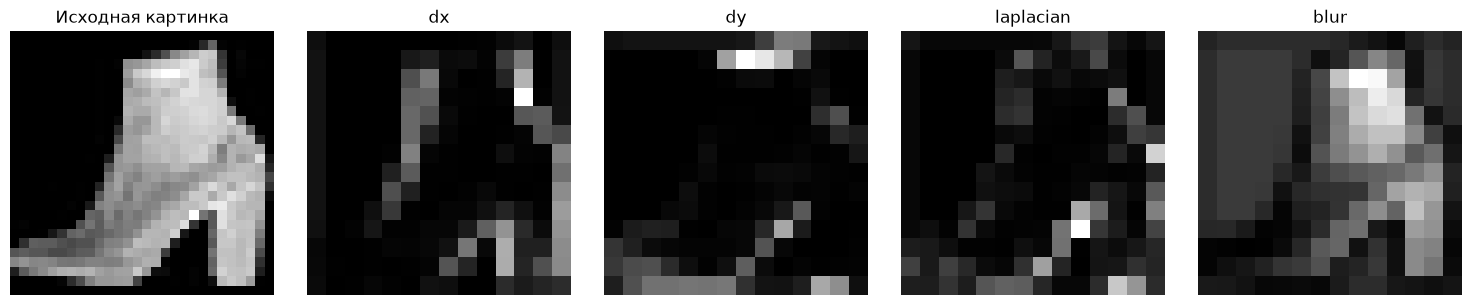

In [3]:
import matplotlib.pyplot as plt
import torch

from optical_differentiation.data import get_dataloaders
from optical_differentiation.optical import OpticalFrontend

train_loader, _ = get_dataloaders(batch_size=8)
images, labels = next(iter(train_loader))

frontend = OpticalFrontend()
frontend.eval()
with torch.no_grad():
    out = frontend(images)   # [8, 4, 14, 14]

channel_names = ["dx", "dy", "laplacian", "blur"]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(images[0, 0], cmap="gray")
axes[0].set_title("Исходная картинка")
axes[0].axis("off")

for i, name in enumerate(channel_names):
    axes[i + 1].imshow(out[0, i], cmap="gray")
    axes[i + 1].set_title(name)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()